In [1]:
from datasets import load_dataset

dataset = load_dataset("pavanmantha/medical-symptoms-disease-classification")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'labels'],
        num_rows: 853
    })
    test: Dataset({
        features: ['text', 'label', 'labels'],
        num_rows: 212
    })
})


In [2]:
import pandas as pd

df = pd.DataFrame(dataset['train'])
df.head()

,text,label,labels
0,I've been having a lot of pain in my neck and ...,cervical spondylosis,3
1,I have a rash on my face that is getting worse...,impetigo,12
2,I have been urinating blood. I sometimes feel ...,urinary tract infection,20
3,I have been having trouble with my muscles and...,arthritis,1
4,I have been feeling really sick. My body hurts...,dengue,6


In [3]:
def format_prompts_train(examples):
  instruction = "Classify the sicknes based on the following description: "
  inputs = examples['text']
  outputs = examples['label']

  texts = []
  for i, o in zip(inputs, outputs):
    text = f"{instruction}\n Input: {i}\n Output: {o}"
    texts.append(text)
  return {"text": texts}

dataset_train = dataset['train'].map(
    format_prompts_train,
    batched = True,
    remove_columns = dataset['train'].column_names
)

In [4]:
dataset_train

Dataset({
    features: ['text'],
    num_rows: 853
})

In [5]:
df_train = pd.DataFrame(dataset_train)

df_train.head()

,text
0,Classify the sicknes based on the following de...
1,Classify the sicknes based on the following de...
2,Classify the sicknes based on the following de...
3,Classify the sicknes based on the following de...
4,Classify the sicknes based on the following de...


In [6]:
def format_prompts_test(examples):
  instruction = "Classify the sicknes based on the following description: "
  inputs = examples['text']
  outputs = examples['label']

  texts = []
  for i, o in zip(inputs, outputs):
    text = f"{instruction}\n Input: {i}\n Output: "
    texts.append(text)
  return {"text": texts}

dataset_test = dataset['test'].map(format_prompts_test, batched = True)

df_test = pd.DataFrame(dataset_test)
df_test.head()

,text,label,labels
0,Classify the sicknes based on the following de...,peptic ulcer disease,16
1,Classify the sicknes based on the following de...,peptic ulcer disease,16
2,Classify the sicknes based on the following de...,drug reaction,8
3,Classify the sicknes based on the following de...,pneumonia,17
4,Classify the sicknes based on the following de...,fungal infection,9


# Baseline

In [19]:
from unsloth import FastLanguageModel
import torch

model_base, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/mistral-7b-v0.3-bnb-4bit",
    max_seq_length = 512,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model_base)

==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096, padding_idx=770)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_lay

In [20]:
def batch_inference_base(dataset_segment, batch_size=16):
    all_preds = []
    for i in range(0, len(dataset_segment), batch_size):
        batch = dataset_segment[i : i + batch_size]
        inputs = tokenizer(batch["text"], return_tensors="pt", padding=True).to("cuda")

        outputs = model_base.generate(
            **inputs,
            max_new_tokens=15,
            temperature=0.1,
            repetition_penalty=1.2
        )

        input_len = inputs.input_ids.shape[1]
        decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)
        all_preds.extend([res.strip().split('\n')[0] for res in decoded])
    return all_preds

predictions_base = batch_inference_base(dataset_test, batch_size=16)

labels_reais = dataset['test']['label']

from sklearn.metrics import classification_report
print(classification_report(labels_reais, predictions_base))

Both `max_new_tokens` (=15) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

--- PERFORMANCE MODELO BASE (SEM FINE-TUNING) ---
                                                                 precision    recall  f1-score   support

                                1) Acne vulgaris (Acne), 2) Ros       0.00      0.00      0.00       0.0
                          1) Allergic reaction, 2) Infection, 3       0.00      0.00      0.00       0.0
                               1) Allergies, 2) Common Cold, 3)       0.00      0.00      0.00       0.0
                          1) Alzheimer's disease, 2) Parkinson'       0.00      0.00      0.00       0.0
                           1) Anorexia nervosa (2) Bulimia nerv       0.00      0.00      0.00       0.0
                                    1) Anxiety, 2) Cold or Flu,       0.00      0.00      0.00       0.0
                      1) Appendicitis  2) Kidney stones   3) Ur       0.00      0.00      0.00       0.0
                          1) Appendicitis, 2) Food poisoning, 3       0.00      0.00      0.00       0.0
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Fine-tuning with QLoRA

In [7]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name='unsloth/mistral-7b-v0.3-bnb-4bit',
    load_in_4bit=True
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [8]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth'
)

Unsloth 2026.4.4 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [9]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset_train,
    dataset_text_field = "text",
    max_seq_length = 128,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_steps = 5,
        max_steps = 60,
        num_train_epochs=2,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

In [10]:
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

In [11]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 853 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,289,966,592 (0.58% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,3.008521
2,2.727638
3,2.334121
4,2.194076
5,1.690598
6,1.336584
7,1.233009
8,1.140832
9,1.140600
10,1.297970


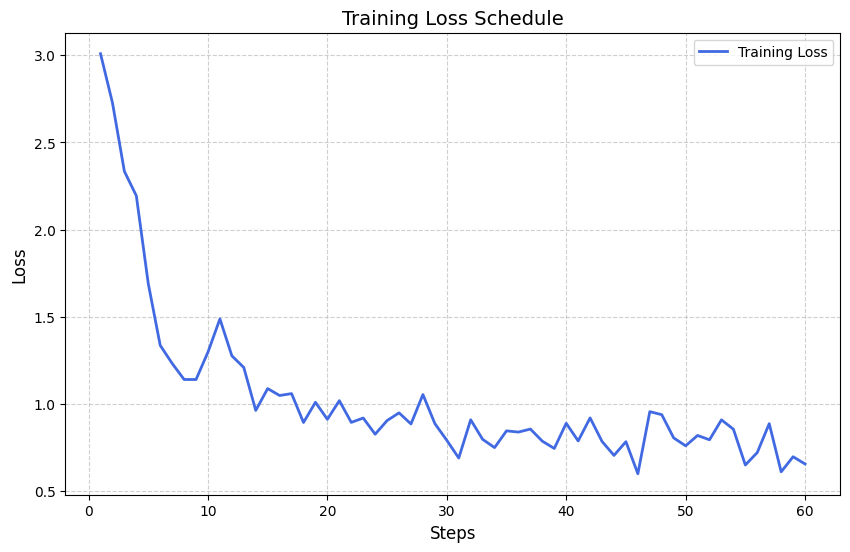

In [29]:
import matplotlib.pyplot as plt

history = trainer_stats.metrics
steps = [x['step'] for x in trainer.state.log_history if 'loss' in x]
loss = [x['loss'] for x in trainer.state.log_history if 'loss' in x]

plt.figure(figsize=(10, 6))
plt.plot(steps, loss, label='Training Loss', color='royalblue', linewidth=2)

plt.title('Training Loss Schedule', fontsize=14)
plt.xlabel('Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig("loss_chart.png", dpi=300)
plt.show()

In [16]:
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32768, 4096, padding_idx=770)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj):

In [ ]:
import torch
from sklearn.metrics import classification_report

labels_reais = dataset['test']['label']

tokenizer.padding_side = "left"

def batch_inference(dataset_segment, batch_size=16):
    all_preds = []
    for i in range(0, len(dataset_segment), batch_size):
        batch = dataset_segment[i : i + batch_size]
        inputs = tokenizer(batch["text"], return_tensors="pt", padding=True).to("cuda")

        outputs = model.generate(
            **inputs,
            max_new_tokens=15,
            temperature=0.1,
            use_cache=True,
            repetition_penalty=1.2
        )

        input_len = inputs.input_ids.shape[1]
        decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)
        all_preds.extend([res.strip().split('\n')[0] for res in decoded])

    return all_preds

predictions = batch_inference(dataset_test, batch_size=16)

In [17]:
from difflib import get_close_matches

labels_validas = list(set(dataset['train']['label']))

def normalizar_predicao(pred):
    match = get_close_matches(pred, labels_validas, n=1, cutoff=0.3)
    return match[0] if match else pred

predictions_normalizadas = [normalizar_predicao(p) for p in predictions]
print(classification_report(labels_reais, predictions_normalizadas))

                                 precision    recall  f1-score   support

                        allergy       1.00      0.70      0.82        10
                      arthritis       1.00      1.00      1.00        10
               bronchial asthma       0.56      0.90      0.69        10
           cervical spondylosis       1.00      1.00      1.00        10
                    chicken pox       0.89      0.80      0.84        10
                    common cold       0.75      0.90      0.82        10
                         dengue       0.47      0.80      0.59        10
                       diabetes       0.78      0.70      0.74        10
                  drug reaction       0.67      0.25      0.36         8
               fungal infection       0.90      1.00      0.95         9
gastroesophageal reflux disease       0.71      1.00      0.83        10
                   hypertension       0.71      1.00      0.83        10
                       impetigo       1.00      0.

In [18]:
model.save_pretrained("fine-tuning-mistral-7b-medical")
tokenizer.save_pretrained("fine-tuning-mistral-7b-medical")

('fine-tuning-mistral-7b-medical/tokenizer_config.json',
 'fine-tuning-mistral-7b-medical/tokenizer.json')

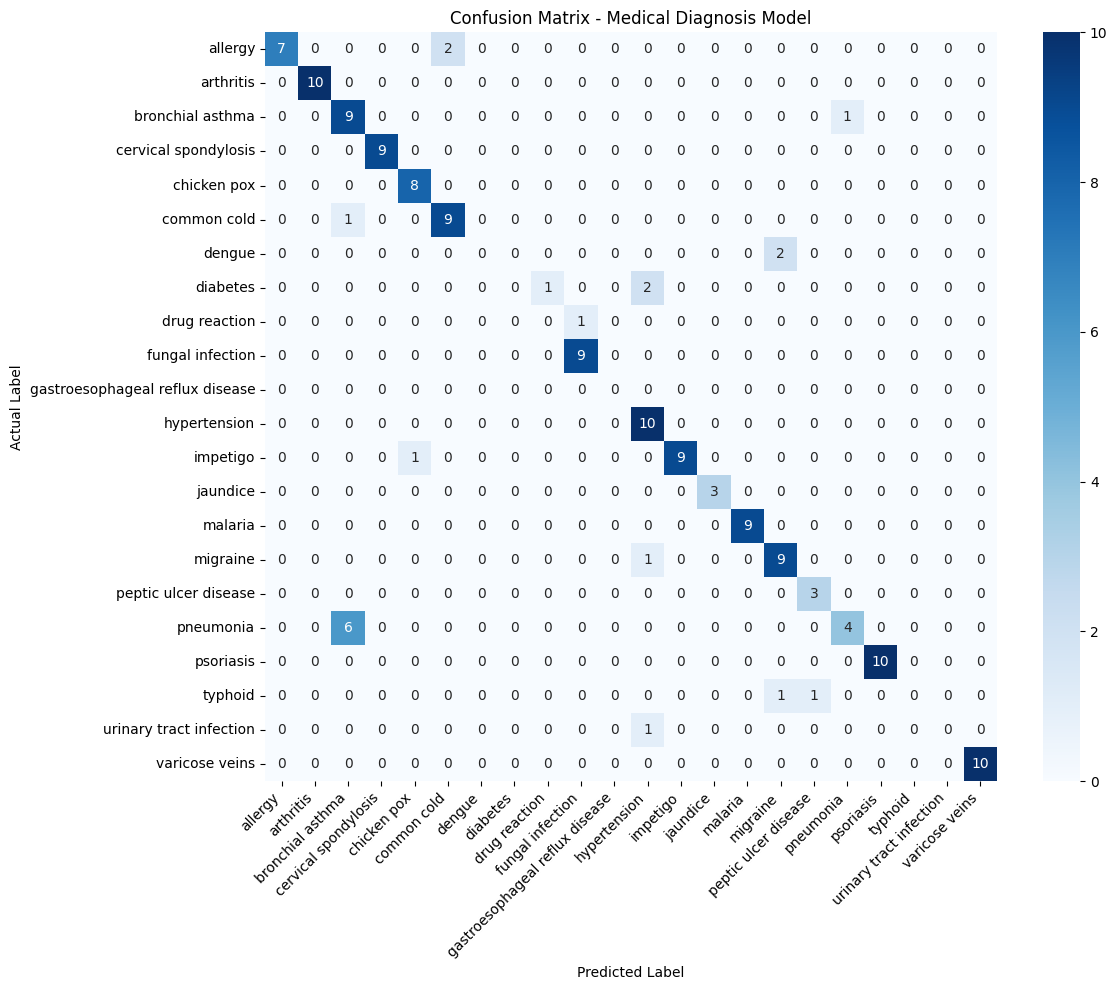

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

classes = sorted(list(set(labels_reais)))

cm = confusion_matrix(labels_reais, predictions, labels=classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.title('Confusion Matrix - Medical Diagnosis Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

#### The model frequently misclassifies Pneumonia as Bronchial Asthma. This is attributed to the symptomatic overlap in features like cough and dyspnea. Improving the model would require specific clinical markers such as 'High Fever' or 'Wheezing' to be more prevalent in the training prompts

# Inference with interface

In [24]:
def predict_desiease(symptoms_text):
    prompt = f"Classify the sicknes based on the following description:\n Input:\n{symptoms_text}\n Output:\n"

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=15,
        temperature=0.1,
        use_cache=True,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    input_len = inputs.input_ids.shape[1]
    decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)

    return decoded[0].strip().split('\n')[0]


In [27]:
import gradio as gr

def predict_ui(sintomas):
    if not sintomas.strip():
        return "Insert the symptoms for analysis."

    resultado = predict_desiease(sintomas)
    return resultado

demo = gr.Interface(
    fn=predict_ui,
    inputs=gr.Textbox(lines=5, label="Discribe the symptoms", placeholder="Ex: fever, cough, joint pain..."),
    outputs=gr.Textbox(label="Probable diagnosis"),
    title="AI Medical Classifier (Mistral-7B QLoRA)",
    description="Testing interface for a desiease classification model trained via Fine-tuning with QLoRA.",
    theme="soft"
)

demo.launch(share=True) # O 'share=True' cria o link público na hora!

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3780a770855839aaad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
